In [11]:
# Importing necessary libraries
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import joblib
import logging
from collections import Counter
from nltk.util import ngrams
from imblearn.over_sampling import RandomOverSampler  # Import RandomOverSampler

# Configure logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")


In [12]:
# Defining the file location
file_path = "Sarcasm_Headlines_Dataset.json"

# Load the dataset
logging.info("Loading the dataset...")
df = pd.read_json(file_path, lines=True)


2025-01-14 00:17:31,807 - Loading the dataset...


In [13]:
# Preprocess the text data
def preprocess_text(text):
    """
    Cleans text by removing URLs, special characters, and extra whitespace.
    Converts text to lowercase.
    """
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower().strip()
    return text



Class Distribution:
0    14985
1    11724
Name: is_sarcastic, dtype: int64


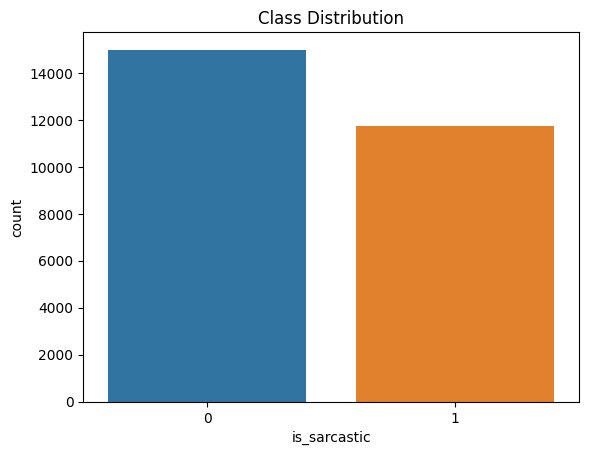


Headline Length Statistics:
count    26709.000000
mean         9.845820
std          3.168955
min          2.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         39.000000
Name: headline_length, dtype: float64


In [14]:
# Class distribution
class_counts = df["is_sarcastic"].value_counts()
print("\nClass Distribution:")
print(class_counts)

# Class distribution bar plot
sns.countplot(x="is_sarcastic", data=df)
plt.title("Class Distribution")
plt.show()

# Headline length statistics
df["headline_length"] = df["headline"].apply(lambda x: len(x.split()))
print("\nHeadline Length Statistics:")
print(df["headline_length"].describe())


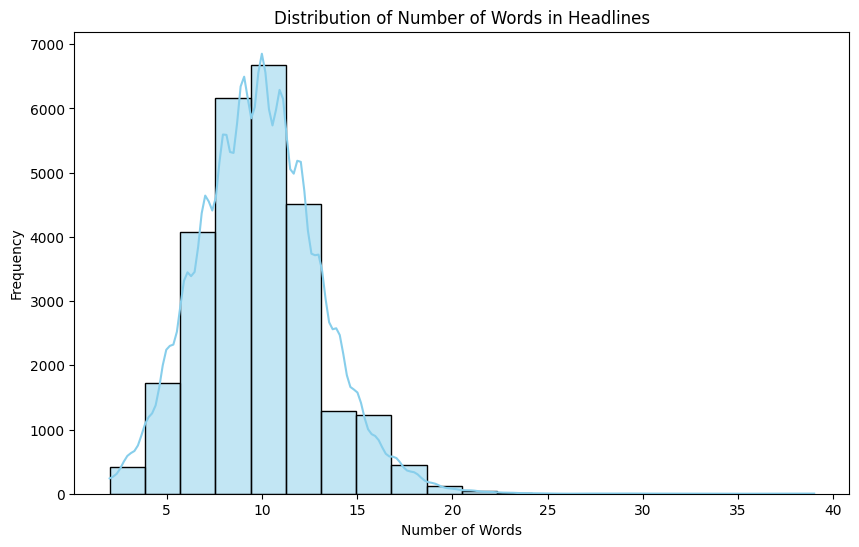


Top 10 Bigrams:
[('donald trump', 94.50561468170469), ('area man', 66.3742831710325), ('year old', 55.21967021644491), ('hillary clinton', 44.7181860092727), ('white house', 40.678392080737275), ('supreme court', 28.67089962847065), ('new york', 28.4442363492663), ('study finds', 26.932783275731634), ('bernie sanders', 20.81937797304818), ('high school', 20.650904673059998)]

Top 10 Trigrams:
[('huffpost rise need', 10.839388969739408), ('rise need know', 10.839388969739408), ('new study finds', 10.266717217779686), ('funniest tweets women', 9.046706094449076), ('tweets women week', 9.046706094449076), ('new york times', 6.1924114134060275), ('20 funniest tweets', 5.9410081559440835), ('friday morning email', 5.557622647636622), ('new york city', 5.166429810858917), ('friday talking points', 5.09691744956384)]


In [15]:
# Histogram for number of words in headlines
plt.figure(figsize=(10, 6))
sns.histplot(df["headline_length"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Number of Words in Headlines")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Top bigrams and trigrams
def get_top_ngrams(corpus, n=None, ngram_range=(2, 3)):
    vec = TfidfVectorizer(ngram_range=ngram_range, stop_words="english")
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

top_bigrams = get_top_ngrams(df["headline"], n=10, ngram_range=(2, 2))
print("\nTop 10 Bigrams:")
print(top_bigrams)

top_trigrams = get_top_ngrams(df["headline"], n=10, ngram_range=(3, 3))
print("\nTop 10 Trigrams:")
print(top_trigrams)

In [10]:
# Step 4: Train and evaluate the model

# Preprocess the 'headline' column
logging.info("Preprocessing text...")
df["headline"] = df["headline"].apply(preprocess_text)

# Features (X) and Labels (y)
X = df["headline"]
y = df["is_sarcastic"]

# Split data into training and test sets
logging.info("Splitting data into training and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Applying Random Over Sampler for class balancing
logging.info("Balancing classes using RandomOverSampler...")
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train.values.reshape(-1, 1), y_train)

# Define the pipeline
pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 3),
                stop_words="english",
            ),
        ),
        ("rf", RandomForestClassifier(random_state=42)),
    ]
)

# Hyperparameter tuning with GridSearchCV
logging.info("Tuning hyperparameters...")
param_grid = {
    "rf__n_estimators": [500, 1000, 1500],
    "rf__max_depth": [10, 50, 100],
}
grid_search = GridSearchCV(
    pipeline, param_grid, cv=3, scoring="f1", verbose=1, n_jobs=-1
)
grid_search.fit(X_train_resampled.flatten(), y_train_resampled)

# Best model
best_model = grid_search.best_estimator_
logging.info(f"Best Parameters: {grid_search.best_params_}")


2025-01-14 00:17:33,943 - Preprocessing text...
2025-01-14 00:17:34,027 - Splitting data into training and test sets...
2025-01-14 00:17:34,039 - Balancing classes using RandomOverSampler...
2025-01-14 00:17:34,045 - Tuning hyperparameters...


Fitting 3 folds for each of 9 candidates, totalling 27 fits


In [ ]:
# Evaluate the model on training data
logging.info("Evaluating the model on training data...")
y_train_pred = best_model.predict(X_train)

print("\nTraining Data Metrics:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.2f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.2f}")
print(f"Recall: {recall_score(y_train, y_train_pred):.2f}")
print(f"F1 Score: {f1_score(y_train, y_train_pred):.2f}")
print("\nClassification Report (Training Data):")
print(classification_report(y_train, y_train_pred))

# Evaluate the model on test data
logging.info("Evaluating the model on test data...")
y_test_pred = best_model.predict(X_test)

print("\nTest Data Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred):.2f}")
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# Save the model and vectorizer
logging.info("Saving the model and vectorizer...")
joblib.dump(best_model, "sarcasm_model.pkl")
logging.info("Model saved successfully!")